# Filtracja bilateralna

## Konwolucja obrazu z filtrem o zadanych współczynnikach

Splot (konwolucję) obrazu wejściowego $I$ z filtrem $\psi$ dla ustalonego punktu obrazu $\mathbf{x}$ można przedstawić następująco:

\begin{equation}
\hat{I}(\mathbf{x}) = \frac{1}{W_N}\sum_{\mathbf{p} \in \eta(\mathbf{x})} \psi(||\mathbf{p}-\mathbf{x}||)I(\mathbf{p})
\tag{1}
\end{equation}

gdzie:
- $\hat{I}$ jest obrazem wynikowym (przefiltrowanym),
- $W_N = \sum_y \psi(y)$ jest parametrem normalizującym współczynniki filtra $\psi$,
- $||\cdot||$ jest odległością między punktami obrazu $\mathbf{x}$ i $\mathbf{p}$ według ustalonej metryki (np. norma $L_2$). Uwaga, proszę pamiętać, że zarówno $\mathbf{x}$, jak i $\mathbf{p}$ to współrzędne przestrzenne,
- $\eta(\mathbf{x})$ jest otoczeniem punktu $\mathbf{x}$.

Funkcja $\psi$ decyduje o charakterze filtracji. Dla filtru Gaussowskiego:

\begin{equation}
\psi(y) = G_{\delta_s}(y)
\tag{2}
\end{equation}

gdzie: $G_{\delta_s}(y)$ jest funkcją Gaussa z parametrem skali $\delta_s$.

Opisaną powyżej filtrację realizowaliśmy w ramach ćwiczenia "Przetwarzanie wstępne. Filtracja kontekstowa."

## Filtracja bilateralna

Wadą klasycznego splotu jest brak adaptacji współczynników filtra do lokalnego otoczenia $\eta(\mathbf{x})$ filtrowanego punktu $\mathbf{x}$.
Oznacza to wykorzystanie tych samych współczynników filtra $\psi$ niezależnie od tego czy otoczenie jest względnie jednorodne lub zawiera krawędzie obiektów (w tym przypadku dochodzi do "rozmywania" krawędzi).
Filtracja bilateralna uwzględnia lokalne otoczenie filtrowanego punktu, w ten sposób, że parametry filtra zmieniają się w zależności od "wyglądu" otoczenia.


Współczynniki filtra obliczane są na podstawie odległości filtrowanego punktu $\mathbf{x}$ od każdego punktu otoczenia $\mathbf{p}$ w dziedzinie przestrzennej obrazu (tak jak przy typowym filtrze np. Gaussa) oraz odległości punktów w przeciwdziedzinie obrazu (np. na podstawie różnicy w jasności pikseli dla obrazu w odcieniach szarości):

\begin{equation}
\hat{I}(\mathbf{x}) = \frac{1}{W_N}\sum_{\mathbf{p} \in \eta(\mathbf{x})} \psi(||\mathbf{p}-\mathbf{x}||) \gamma(|I(\mathbf{p}) - I(\mathbf{x})|) I(\mathbf{p})
\tag{3}
\end{equation}
gdzie:
- $W_N$ jest współczynnikiem normalizującym filtr,
- $\gamma$ jest funkcją odległości w przeciwdziedzinie obrazu, np. $\gamma(y)=\exp(-\frac{y^2}{2\delta_r^2})$
- parametr $\delta_r$ jest utożsamiany z poziomem szumu w obrazie i należy go dobrać w sposób empiryczny.

Proszę chwilę zastanowić się nad powyższym równaniem, w szczególności nad funkcją $\gamma$. Proszę wyznaczyć, jaka będzie wartość funkcji dla pikseli podobnych (różnica 0, 1, 2), a skrajnie różnych (255, 200).

##  Realizacja ćwiczenia

### Wczytanie danych

1. Wczytaj dane z pliku *MR_data.mat*. W tym celu wykorzystaj funkcję `loadmat` z pakietu scipy:
        from scipy.io import loadmat
        mat = loadmat('MR_data.mat')

2. Wczytany plik zawiera 5 obrazów: *I_noisefree*, *I_noisy1*, *I_noisy2*, *I_noisy3* oraz *I_noisy4*. Odczytać je można w następujący sposób:
        Input = mat['I_noisy1']

3. Wyświetl wybrany obraz z pliku *MR_data.mat*. Zagadka - co to za obrazowanie medyczne?

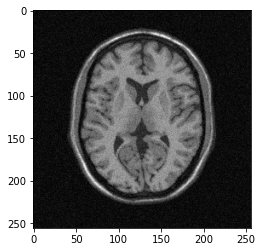

In [1]:
from matplotlib import pyplot as plt
import numpy as np
from scipy.io import loadmat
import math
import os
plt.gray()

if not os.path.exists("MR_data.mat") :
    !wget https://raw.githubusercontent.com/vision-agh/poc_sw/master/07_Bilateral/MR_data.mat --no-check-certificate

#TODO Samodzielna

mat=loadmat('MR_data.mat')
i=mat['I_noisefree']
i1=mat['I_noisy1']
i2=mat['I_noisy2']
i3=mat['I_noisy3']
i4=mat['I_noisy4']

plt.imshow(i1)


In [2]:
def three_pictures(im1,im2,im3):
     fig,ax=plt.subplots(1,3,figsize=(5,15))
     ax[0].imshow(im1)
     ax[1].imshow(im2)
     ax[2].imshow(im3)
     ax[0].axis('off')
     ax[1].axis('off')
     ax[2].axis('off')

### "Klasyczna" konwolucja

1. Zdefiniuj parametry filtra Gaussowskiego: rozmiar okna i wariancję $\delta_S$.
2. Oblicz współczynniki filtra na podstawie zdefiniowanych parametrów (najprościej w ramach podwójnej pętli for).
2. Sprawdź ich poprawność i zwizualizuj filtr (tak jak w ćwiczeniu pt. "Przetwarzanie wstępne. Filtracja kontekstowa.").
3. Wykonaj kopię obrazu wejściowego: `IConv = Input.copy()`
4. Wykonaj podwójną pętlę po obrazie. Pomiń ramkę, dla której nie jest zdefiniowany kontekst o wybranej wielkości.
5. W każdej iteracji stwórz dwuwymiarową tablicę zawierającą aktualny kontekst.
6. Napisz funkcję, która będzie obliczała nową wartość piksela.
Argumentem tej funkcji są aktualnie przetwarzane okno i współczynniki filtra.
7. Obliczoną wartość przypisz do odpowiedniego piksela kopii obrazu wejściowego.
8. Wyświetl wynik filtracji.
9. Porównaj wynik z obrazem oryginalnym.

In [9]:
siz=5
v=1

In [12]:
def fgaus(size, sigma):
     m = n = size
     h, k = m//2, n//2
     x, y = np.mgrid[-h:h+1, -k:k+1]
     g = np.exp(-(x**2 + y**2)/(2*sigma**2))
     return g 

def fgaussian(size, sigma):
     m = n = size
     h, k = m//2, n//2
     x, y = np.mgrid[-h:h+1, -k:k+1]
     g = np.exp(-(x**2 + y**2)/(2*sigma**2))
     return g /g.sum() 

def mesh(fun, size):
    fig = plt.figure()
    ax = fig.gca(projection='3d')
    

    X = np.arange(-size//2, size//2, 1)
    Y = np.arange(-size//2, size//2, 1)
    X, Y = np.meshgrid(X, Y)
    Z = fun
    
    ax.plot_surface(X, Y, Z)
    
    plt.show()

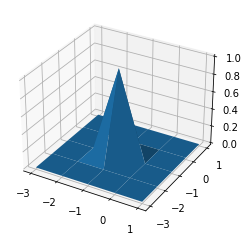

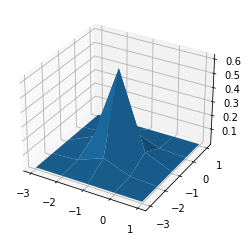

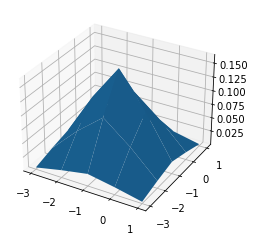

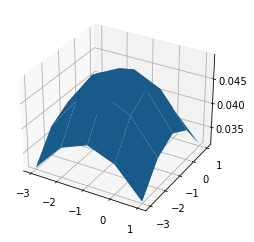

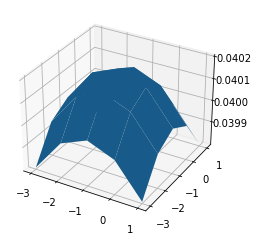

In [ ]:
m1=mesh(fgaussian(5,0.1),5)
m2=mesh(fgaussian(5,0.5),5)
m3=mesh(fgaussian(5,1),5)
m4=mesh(fgaussian(5,3),5)
m5=mesh(fgaussian(5,20),5)



In [39]:
def nev(slice,var):
    x,y =slice.shape
    xx=int(x/2)
    yy=int(y/2)
    pix=0
    s=0
    for i in range(x):
        for j in range(y):
            ym=np.sqrt(((xx-i)**2)+((yy-j)**2))
            g=np.exp(-(ym**2)/(2*(var**2)))
            pix+=g*slice[i,j]
            s+=g
    pix/=fgaus(x,var).sum()
    return pix

def classic(img,siz,var):
    IConv=img.copy()
    x,y=IConv.shape
    sizz=int(siz/2)
    for i in range(0+sizz,x-sizz):
        for j in range(0+sizz,y-sizz):
            IConv[i,j]=nev(IConv[i-sizz:i+sizz+1,j-sizz:j+sizz+1],var)
    return IConv

new=classic(i2,7,0.9)

Text(0.5, 1.0, 'convolved')

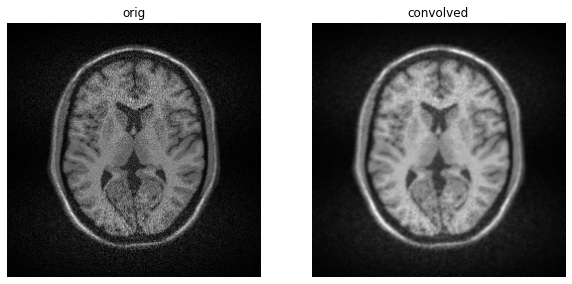

In [40]:
fig,ax=plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(i2)
ax[1].imshow(new)
ax[0].axis('off')
ax[1].axis('off')
ax[0].set_title('orig')
ax[1].set_title('convolved')

Drugi obraz jest rozjaśniony, widać też na nim mniej szumu.

### Filtracja bilateralna

1. Zdefiniuj dodatkowy parametr: wariancję $\delta_R$.
3. Wykonaj kopię obrazu wejściowego: `IBilateral = Input.copy()`
4. Wykonaj podwójną pętlę po obrazie. Pomiń ramkę, dla której nie jest zdefiniowany kontekst o wybranej wielkości.
5. W każdej iteracji stwórz dwuwymiarową tablicę zawierającą aktualny kontekst.
6. Napisz funkcję, która będzie obliczała nową wartość piksela.
Argumentami funkcji są aktualnie przetwarzane okno, współczynniki filtra gaussowskiego (takie same jak wcześniej) i wariancja $\delta_R$.
7. Oblicz odległość w przeciwdziedzinie (dla wartości pikseli).
8. Oblicz funkcję Gaussa dla obliczonych odległości z zadanym parametrem.
9. Wykonaj normalizację obliczonych współczynników.
10. Obliczoną wartość przypisz do odpowiedniego piksela kopii obrazu wejściowego.
11. Wyświetl wynik filtracji.
12. Porównaj wynik z obrazem oryginalnym.

In [44]:
def bilp(slice,var,delt):
    x,y =slice.shape
    xx=int(x/2)
    yy=int(y/2)
    pix=0
    s=0
    for i in range(x):
        for j in range(y):
            ym=np.sqrt(((xx-i)**2)+((yy-j)**2))
            g=np.exp(-(ym**2)/(2*(var**2)))
            dif=np.abs(slice[xx,yy]-slice[i,j])
            gdif=np.exp(-(dif**2)/(2*(delt**2)))
            pix+=g*gdif*slice[i,j]
            s+=g*gdif
    pix/=gdif
    return pix

def bil(img,siz,var,delt):
    IConv=img.copy()
    x,y=IConv.shape
    sizz=int(siz/2)
    for i in range(0+sizz,x-sizz):
        for j in range(0+sizz,y-sizz):
            IConv[i,j]=bilp(IConv[i-sizz:i+sizz+1,j-sizz:j+sizz+1],var,delt)
    return IConv


In [47]:
from scipy import signal
p=i3
v=0.8
siz=3

p1=classic(p,siz,v)
p3=signal.convolve2d(p,fgaussian(siz,v))

<ipython-input-44-1a646fc90b80>:11: RuntimeWarning: overflow encountered in ubyte_scalars
  dif=np.abs(slice[xx,yy]-slice[i,j])


In [55]:
d=30
p2=bil(p,siz,3,d)

<ipython-input-44-1a646fc90b80>:11: RuntimeWarning: overflow encountered in ubyte_scalars
  dif=np.abs(slice[xx,yy]-slice[i,j])


Text(0.5, 1.0, 'signal')

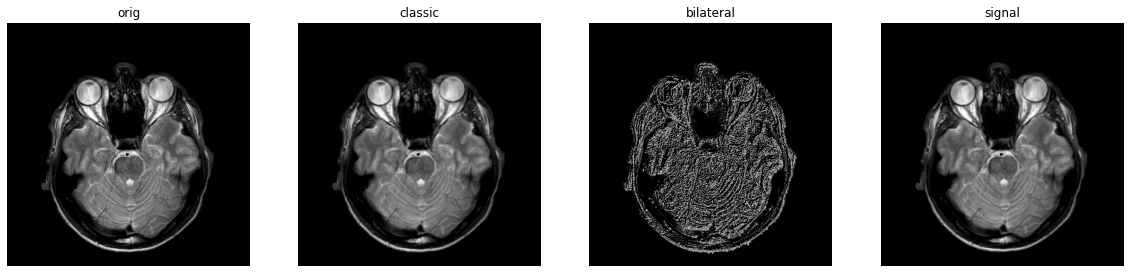

In [56]:
fig,ax=plt.subplots(1,4,figsize=(20,5))
ax[0].imshow(p)
ax[1].imshow(p1)
ax[2].imshow(p2)
ax[3].imshow(p3)
ax[0].axis('off')
ax[1].axis('off')
ax[2].axis('off')
ax[3].axis('off')
ax[0].set_title('orig')
ax[1].set_title('classic')
ax[2].set_title('bilateral')
ax[3].set_title('signal')